# Exploratory Data Analysis of NSW Electricity Demand

## Section 1 - Introduction

This notebook performs exploratory data analysis (EDA) on electricity demand in New South Wales (NSW). The analysis investigates the relationships between electricity demand, temperature, and the provided forecast series. Machine learning models are later developed to generate demand forecasts and compare them against the provided forecast under a consistent evaluation setting.

## Section 2 - Data Loading

We load three datasets:

• Total electricity demand  
• Temperature observations  
• Forecast electricity demand  

These datasets will later be merged using the DATETIME field.

In [ ]:
!git clone https://github.com/laukamkit/capstone_project_GroupA.git

In [ ]:
!ls /content/capstone_project_GroupA/data/NSW

In [1]:
import os
# repo_path = ".." if using local machine and not colab. otherwise, "/content/capstone_project_GroupA".
repo_path = ".."
nsw_path = os.path.join(repo_path, "data", "NSW")

part_a = os.path.join(nsw_path, "forecastdemand_nsw.csv.zip.partaa")
part_b = os.path.join(nsw_path, "forecastdemand_nsw.csv.zip.partab")
forecast_zip = os.path.join(nsw_path, "forecastdemand_nsw.csv.zip")

with open(forecast_zip, "wb") as outfile:
    for p in [part_a, part_b]:
        with open(p, "rb") as infile:
            outfile.write(infile.read())

print("Created:", forecast_zip)
print("Files:", os.listdir(nsw_path))

Created: ..\data\NSW\forecastdemand_nsw.csv.zip
Files: ['df_model.csv', 'forecastdemand_nsw.csv.zip', 'forecastdemand_nsw.csv.zip.partaa', 'forecastdemand_nsw.csv.zip.partab', 'scaler.pkl', 'temperature_nsw.csv.zip', 'test.csv', 'test_scaled.csv', 'totaldemand_nsw.csv.zip', 'train.csv', 'train_scaled.csv', 'validation.csv', 'val_scaled.csv']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_demand = pd.read_csv(
    os.path.join(nsw_path, "totaldemand_nsw.csv.zip")
)

df_temp = pd.read_csv(
    os.path.join(nsw_path, "temperature_nsw.csv.zip")
)

df_forecast = pd.read_csv(
    os.path.join(nsw_path, "forecastdemand_nsw.csv.zip")
)


## Section 3 - Dataset Overview

Before performing analysis, we inspect the size and structure of each dataset.

In [3]:
print("Demand shape:", df_demand.shape)
print("Demand columns:", df_demand.columns.tolist())
print("Temp shape:", df_temp.shape)
print("Temp columns:", df_temp.columns.tolist())
print("Forecast shape:", df_forecast.shape)
print("Forecast columns:", df_forecast.columns.tolist())

Demand shape: (196513, 3)
Demand columns: ['DATETIME', 'TOTALDEMAND', 'REGIONID']
Temp shape: (220326, 3)
Temp columns: ['LOCATION', 'DATETIME', 'TEMPERATURE']
Forecast shape: (10906019, 6)
Forecast columns: ['PREDISPATCHSEQNO', 'REGIONID', 'PERIODID', 'FORECASTDEMAND', 'LASTCHANGED', 'DATETIME']


In [4]:
print(df_temp["LOCATION"].unique())
print(df_demand["REGIONID"].unique())

<ArrowStringArray>
['Bankstown']
Length: 1, dtype: str
<ArrowStringArray>
['NSW1']
Length: 1, dtype: str


After examining the categorical variables using unique(), it is observed that the LOCATION field contains only one value, Bankstown, and the REGIONID field contains only one value, NSW1. Since both variables have only a single category, they do not introduce any variation into the dataset and therefore do not introduce variability and therefore provide no explanatory power for modelling purposes. As a result, these two fields are going to be excluded from the merged dataset.

## Section 4 - Data Preparation

The forecast dataset contains multiple forecast records for each timestamp because forecasts are stored by lead time (PERIODID). Therefore, instead of averaging forecast values across all periods, the provided forecast series was aligned using the forecast step relevant to the evaluation horizon. The resulting forecast series was then merged with demand and temperature data on DATETIME.

In [5]:
print('\nDatetime parsing comparison for df_demand:')
print('Number of NaT values when using dayfirst=True:', pd.to_datetime(df_demand["DATETIME"], dayfirst=True, errors="coerce").isna().sum())
print('Number of NaT values when using format="%d/%m/%Y %H:%M":', pd.to_datetime(df_demand["DATETIME"], format="%d/%m/%Y %H:%M", errors="coerce").isna().sum())
print('\nDatetime parsing comparison for df_temp:')
print('Number of NaT values when using dayfirst=True:', pd.to_datetime(df_temp["DATETIME"], dayfirst=True, errors="coerce").isna().sum())
print('Number of NaT values when using format="%d/%m/%Y %H:%M":', pd.to_datetime(df_temp["DATETIME"], format="%d/%m/%Y %H:%M", errors="coerce").isna().sum())
print('\nDatetime parsing comparison for df_forecast:')
print('Number of NaT values when using dayfirst=True:', pd.to_datetime(df_forecast["DATETIME"], dayfirst=True, errors="coerce").isna().sum())
print('Number of NaT values when using format="%Y-%m-%d %H:%M:%S":', pd.to_datetime(df_forecast["DATETIME"], format="%Y-%m-%d %H:%M:%S", errors="coerce").isna().sum())


Datetime parsing comparison for df_demand:
Number of NaT values when using dayfirst=True: 0
Number of NaT values when using format="%d/%m/%Y %H:%M": 0

Datetime parsing comparison for df_temp:
Number of NaT values when using dayfirst=True: 0
Number of NaT values when using format="%d/%m/%Y %H:%M": 0

Datetime parsing comparison for df_forecast:
Number of NaT values when using dayfirst=True: 6590548
Number of NaT values when using format="%Y-%m-%d %H:%M:%S": 0


In [6]:
df_forecast

,PREDISPATCHSEQNO,REGIONID,PERIODID,FORECASTDEMAND,LASTCHANGED,DATETIME
0,2009123018,NSW1,71,7832.04,2009-12-30 12:31:49,2010-01-01 00:00:00
1,2009123019,NSW1,70,7832.04,2009-12-30 13:01:43,2010-01-01 00:00:00
2,2009123020,NSW1,69,7832.03,2009-12-30 13:31:36,2010-01-01 00:00:00
3,2009123021,NSW1,68,7832.03,2009-12-30 14:01:44,2010-01-01 00:00:00
4,2009123022,NSW1,67,7830.96,2009-12-30 14:31:35,2010-01-01 00:00:00
...,...,...,...,...,...,...
10906014,2021031736,NSW1,5,7028.45,2021-03-17 21:31:31,2021-03-18 00:00:00
10906015,2021031737,NSW1,4,7041.65,2021-03-17 22:01:34,2021-03-18 00:00:00
10906016,2021031738,NSW1,3,7087.60,2021-03-17 22:31:36,2021-03-18 00:00:00
10906017,2021031739,NSW1,2,7087.28,2021-03-17 23:01:36,2021-03-18 00:00:00


In [7]:
import os
import pandas as pd
import numpy as np
# Convert all DATETIME columns to real datetime
df_forecast["DATETIME"] = pd.to_datetime(df_forecast["DATETIME"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
df_forecast["LASTCHANGED"] = pd.to_datetime(df_forecast["LASTCHANGED"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
df_forecast["TARGET_DATETIME"] = (
    df_forecast["LASTCHANGED"] + pd.to_timedelta(df_forecast["PERIODID"] * 30, unit="m")
)

# Drop rows where DATETIME failed to parse
df_forecast = df_forecast.dropna(subset=["DATETIME"])

# Sort DATETIME
df_forecast = df_forecast.sort_values("DATETIME")

# =========================================================
# --- Forecast target datetime ---
# =========================================================
df_forecast["TARGET_DATETIME"] = pd.to_datetime(df_forecast["TARGET_DATETIME"]).dt.floor("30min")

df_forecast

,PREDISPATCHSEQNO,REGIONID,PERIODID,FORECASTDEMAND,LASTCHANGED,DATETIME,TARGET_DATETIME
0,2009123018,NSW1,71,7832.04,2009-12-30 12:31:49,2010-01-01,2010-01-01
51,2009123121,NSW1,20,7819.50,2009-12-31 14:01:45,2010-01-01,2010-01-01
50,2009123120,NSW1,21,7819.89,2009-12-31 13:31:39,2010-01-01,2010-01-01
49,2009123119,NSW1,22,7817.50,2009-12-31 13:01:46,2010-01-01,2010-01-01
48,2009123118,NSW1,23,7808.85,2009-12-31 12:31:38,2010-01-01,2010-01-01
...,...,...,...,...,...,...,...
10905968,2021031638,NSW1,51,6934.59,2021-03-16 22:31:45,2021-03-18,2021-03-18
10905967,2021031637,NSW1,52,6936.11,2021-03-16 22:01:47,2021-03-18,2021-03-18
10905966,2021031636,NSW1,53,6930.46,2021-03-16 21:31:31,2021-03-18,2021-03-18
10905982,2021031704,NSW1,37,6946.14,2021-03-17 05:31:14,2021-03-18,2021-03-18


In [8]:
# Convert all DATETIME columns to real datetime
df_demand["DATETIME"] = pd.to_datetime(df_demand["DATETIME"], dayfirst=True, errors="coerce")
df_temp["DATETIME"] = pd.to_datetime(df_temp["DATETIME"], dayfirst=True, errors="coerce")

# Drop rows where DATETIME failed to parse
df_demand = df_demand.dropna(subset=["DATETIME"])
df_temp = df_temp.dropna(subset=["DATETIME"])

# Sort DATETIME
df_demand = df_demand.sort_values("DATETIME")
df_temp = df_temp.sort_values("DATETIME")

# Prepare 48-half-hour lag column
df_p48 = df_forecast[df_forecast["PERIODID"] == 48].copy()
df_p48 = df_p48.dropna(subset=["TARGET_DATETIME"])
df_p48 = df_p48.rename(columns={"TARGET_DATETIME": "TARGET_TIME"})

df_p48 = (
    df_p48.sort_values("LASTCHANGED")
    .drop_duplicates(subset=["TARGET_TIME"], keep="last")
)

df_p48 = df_p48[["TARGET_TIME", "FORECASTDEMAND"]]

# Prepare merged data frame
df_merge = (
    df_demand
    .merge(df_temp, on="DATETIME", how="inner")
    .merge(df_p48, left_on="DATETIME", right_on="TARGET_TIME", how="inner")
)

# examine structure of merged database
df_merge.head()
df_merge.info()
df_merge.describe()

<class 'pandas.DataFrame'>
RangeIndex: 130669 entries, 0 to 130668
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATETIME        130669 non-null  datetime64[us]
 1   TOTALDEMAND     130669 non-null  float64       
 2   REGIONID        130669 non-null  str           
 3   LOCATION        130669 non-null  str           
 4   TEMPERATURE     130669 non-null  float64       
 5   TARGET_TIME     130669 non-null  datetime64[us]
 6   FORECASTDEMAND  130669 non-null  float64       
dtypes: datetime64[us](2), float64(3), str(2)
memory usage: 8.6 MB


,DATETIME,TOTALDEMAND,TEMPERATURE,TARGET_TIME,FORECASTDEMAND
count,130669,130669.000000,130669.000000,130669,130669.000000
mean,2015-08-11 23:14:29.467127,8164.163559,17.684034,2015-08-11 23:14:29.467127,8162.578473
min,2010-01-01 00:00:00,5074.630000,-0.500000,2010-01-01 00:00:00,4831.720000
25%,2012-10-23 13:00:00,7217.460000,13.800000,2012-10-23 13:00:00,7198.620000
50%,2015-08-10 03:00:00,8085.120000,18.000000,2015-08-10 03:00:00,8092.700000
75%,2018-06-01 01:00:00,8987.600000,21.500000,2018-06-01 01:00:00,9010.340000
max,2021-03-18 00:00:00,14579.860000,44.700000,2021-03-18 00:00:00,14581.510000
std,NaN,1325.932887,5.718936,NaN,1334.455407


Since forecasts are available for multiple lead times (P01–P48), it is essential to ensure that comparisons between models and the provided forecast are conducted consistently across matching horizons. This prevents mixing forecasts of different lead times, which would otherwise lead to biased evaluation. In this study, alignment is carefully handled to ensure that each prediction is compared against the corresponding target time, enabling a fair and meaningful performance comparison across models.

## Section 5 - Visualization

### (5.1) Electricity Demand over Time

This plot visualises electricity demand across time to identify
long-term patterns and seasonal fluctuations.

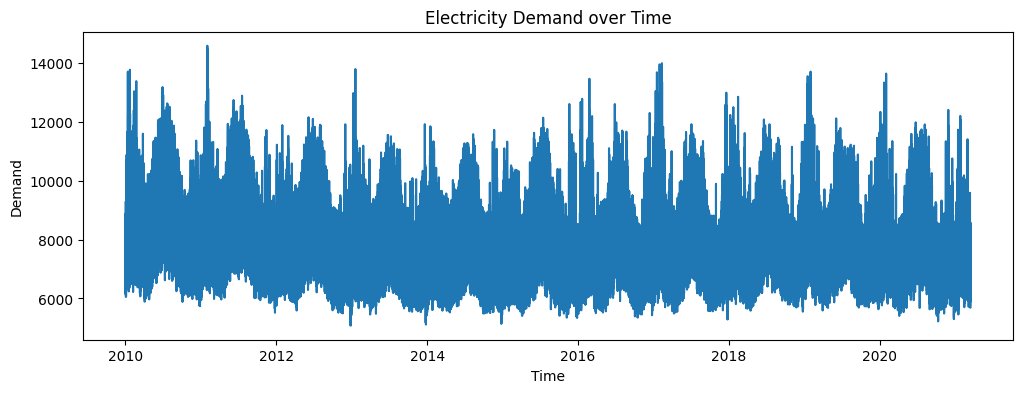

In [9]:
plt.figure(figsize=(12,4))

plt.plot(df_merge["DATETIME"], df_merge["TOTALDEMAND"])

plt.title("Electricity Demand over Time")
plt.xlabel("Time")
plt.ylabel("Demand")

plt.show()

Electricity demand exhibits strong temporal structure, characterised by both short-term fluctuations and long-term seasonal patterns. The repeated cyclical behaviour suggests the presence of daily and yearly seasonality, which is typical in electricity consumption data due to human activity patterns and climate variation.

The presence of clear periodic structure indicates that time-dependent features, such as lag variables or sequence-based models, are essential for accurate forecasting. In particular, models that can capture temporal dependencies (e.g., LSTM or transformer-based architectures) are expected to outperform static models.

### (5.2) Temperature vs Electricity Demand
This plot investigates the relationship between temperature and electricity demand.

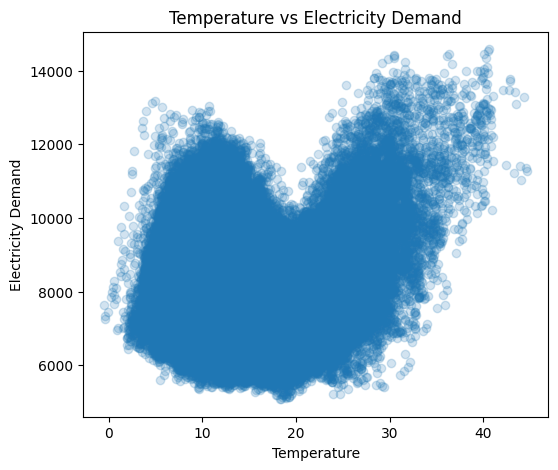

In [10]:
plt.figure(figsize=(6,5))

plt.scatter(
    df_merge["TEMPERATURE"],
    df_merge["TOTALDEMAND"],
    alpha=0.2
)

plt.xlabel("Temperature")
plt.ylabel("Electricity Demand")

plt.title("Temperature vs Electricity Demand")

plt.show()

The relationship between temperature and electricity demand exhibits a pronounced nonlinear U-shaped pattern. Demand increases under both low and high temperature conditions, reflecting heating requirements during colder periods and cooling demand during hotter periods.

This nonlinear relationship explains the relatively weak linear correlation observed earlier and highlights a key limitation of models that assume linear relationships (e.g., basic regression or SARIMAX without transformation).

Therefore, models capable of capturing nonlinear effects, such as tree-based methods or deep learning models, are more appropriate when incorporating temperature as an explanatory variable.

### (5.3) Forecast vs Actual Demand

This plot compares predicted electricity demand with actual demand.


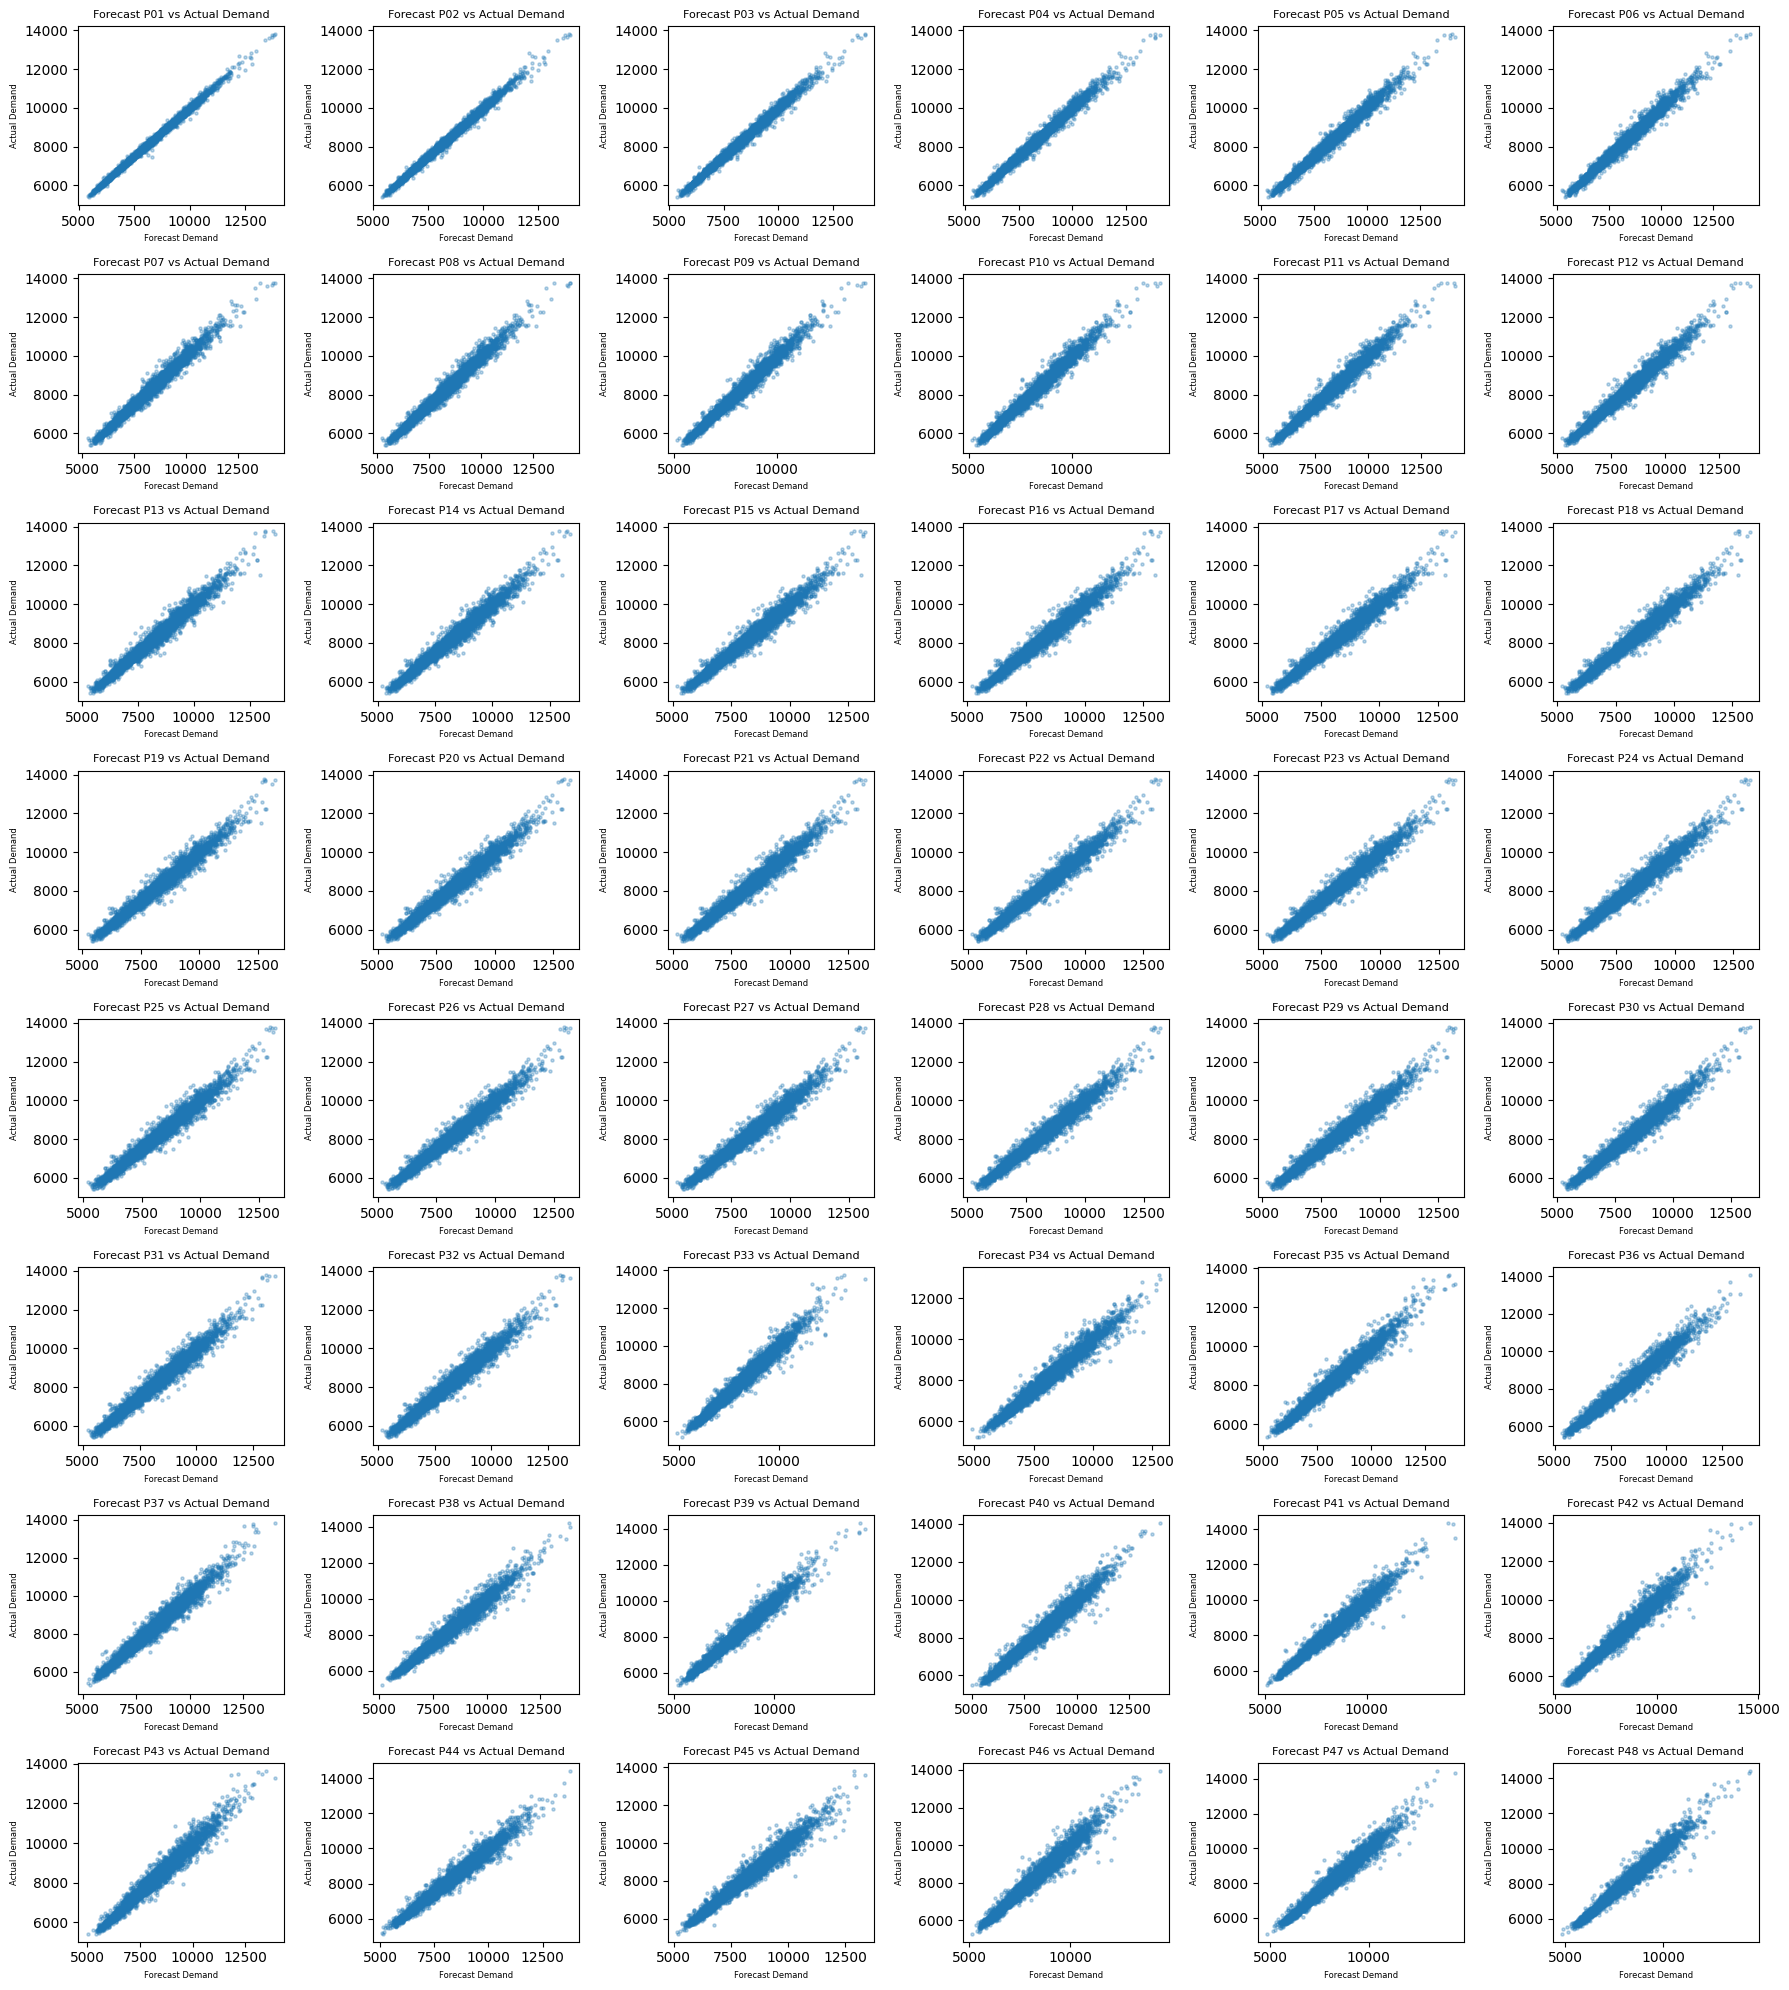

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(8, 6, figsize=(18, 20))
axes = axes.flatten()

for i in range(48):
    p = i + 1
    ax = axes[i]

    df_p = df_forecast[df_forecast["PERIODID"] == p]

    # merge with actual using TARGET_DATETIME
    merged = df_p.merge(
        df_demand,
        left_on="TARGET_DATETIME",
        right_on="DATETIME",
        how="inner"
    )

    merged_sample = merged.sample(5000, random_state=42)

    ax.scatter(
        merged_sample["FORECASTDEMAND"],
        merged_sample["TOTALDEMAND"],
        alpha=0.3,
        s=5
    )

    ax.set_xlabel("Forecast Demand", fontsize=6)
    ax.set_ylabel("Actual Demand", fontsize=6)
    ax.set_title(f"Forecast P{p:02d} vs Actual Demand", fontsize=8)

plt.tight_layout()
plt.show()

The series of scatter plots reveals a clear degradation in forecast accuracy as the prediction horizon increases. This degradation reflects the accumulation of uncertainty in multi-step forecasting, where errors propagate forward as predictions are recursively extended into the future.

For short horizons (P01–P08), predictions are tightly clustered along the diagonal, indicating high accuracy and low variance. However, as the horizon extends towards P48, the dispersion increases significantly, particularly at higher demand levels.

This pattern reflects the accumulation of forecast error in multi-step prediction settings, where uncertainty compounds over time. The widening spread at higher demand levels suggests that extreme demand events are more difficult to predict accurately, which is a critical challenge in electricity forecasting.

These observations establish the provided forecast as a strong short-term benchmark, while also highlighting its limitations for longer horizons. This motivates the development of alternative models aimed at improving medium- and long-term forecasting performance.



### (5.4) Correlation Analysis
For the correlation analysis, a single representative forecast horizon (P48) is used instead of including all forecast steps (P01–P48). This choice is made to maintain interpretability and avoid excessive dimensionality in the correlation matrix, as including all horizons would result in a highly redundant and cluttered representation. Since forecasts across different horizons are strongly correlated and follow similar patterns, P48 is selected as it represents the longest prediction horizon and therefore reflects the most challenging forecasting scenario. This provides a conservative and informative view of the relationship between forecast demand and actual demand, while the full set of horizons (P01–P48) is used later for comprehensive model evaluation. This distinction ensures that exploratory analysis remains interpretable, while model performance evaluation remains comprehensive and fair across all forecast horizons. This ensures consistency with the model evaluation framework, where forecasting performance is assessed across all horizons (P01–P48) using RMSE and MAE.

The correlation matrix shows the relationships between demand, temperature and forecast demand.  



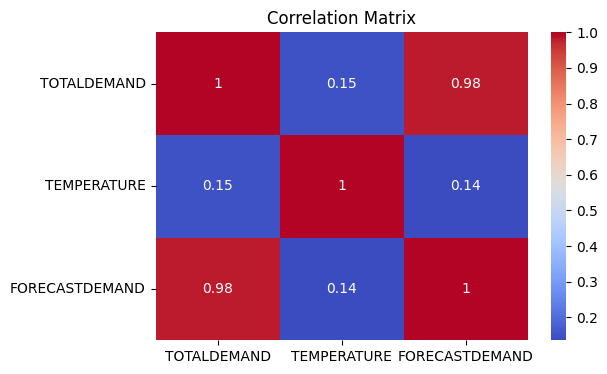

In [12]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    df_merge[["TOTALDEMAND","TEMPERATURE","FORECASTDEMAND"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

The correlation matrix indicates a very strong linear relationship (≈0.98) between the provided forecast and actual demand, confirming that the operational forecasting system closely tracks the underlying demand pattern. A high correlation indicates strong alignment in overall trend but does not guarantee low forecasting error at individual time points, particularly during peak demand periods or longer horizons.

However, the relatively weak correlation between temperature and demand (≈0.15) does not imply that temperature is unimportant. Instead, it reflects the nonlinear and context-dependent nature of the relationship, as previously observed in the U-shaped scatter plot.

This highlights the limitation of relying solely on linear correlation measures and reinforces the need for models capable of capturing nonlinear interactions.

While the correlation between forecast demand and actual demand is extremely high, this result should be interpreted with caution. A strong correlation does not necessarily imply accurate forecasting performance across all horizons, as it primarily reflects similarity in overall trend rather than point-wise accuracy. In particular, forecasting errors may still be substantial during peak demand periods or at longer horizons, as observed in the earlier analysis. Therefore, RMSE and MAE remain essential evaluation metrics to complement correlation-based analysis.

An important observation is that while temperature influences demand, the provided forecast already captures a large proportion of demand variation without explicitly showing strong linear dependence on temperature. This suggests that the operational forecasting system likely incorporates additional latent factors or nonlinear transformations. As a result, improving upon the provided forecast may require models that go beyond simple feature inclusion and instead capture complex temporal interactions.

To further investigate the relationship between temperature and electricity demand, a lagged correlation analysis was conducted, measuring the correlation between demand at time t and temperature at earlier time steps.



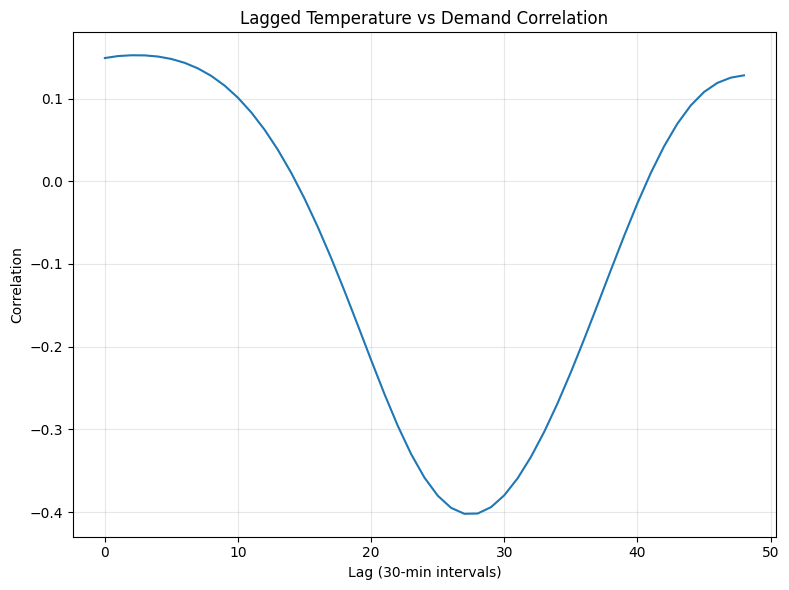

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

temp = pd.read_csv(os.path.join(nsw_path, "temperature_nsw.csv.zip"))
demand = pd.read_csv(os.path.join(nsw_path, "totaldemand_nsw.csv.zip"))

temp["DATETIME"] = pd.to_datetime(temp["DATETIME"], dayfirst=True, errors="coerce")
demand["DATETIME"] = pd.to_datetime(demand["DATETIME"], dayfirst=True, errors="coerce")

temp = temp[temp["LOCATION"] == "Bankstown"][["DATETIME", "TEMPERATURE"]]

temp = (
    temp.set_index("DATETIME")
        .resample("30min")
        .mean()
        .interpolate(method="time")
        .reset_index()
)

df = pd.merge(
    demand[["DATETIME", "TOTALDEMAND"]],
    temp,
    on="DATETIME",
    how="inner"
).dropna()

lags = range(0, 49)   # 0 to 48 half-hour lags
lag_corrs = []

for lag in lags:
    corr = df["TOTALDEMAND"].corr(df["TEMPERATURE"].shift(lag))
    lag_corrs.append(corr)

plt.figure(figsize=(8, 6))
plt.plot(lags, lag_corrs)
plt.xlabel("Lag (30-min intervals)")
plt.ylabel("Correlation")
plt.title("Lagged Temperature vs Demand Correlation")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The lagged correlation analysis reveals that the relationship between temperature and demand is both time-dependent and delayed. While the contemporaneous correlation is weak, the correlation becomes strongly negative at lags around 24–30 intervals (12–15 hours), before rising again, forming a cyclical pattern.

This behaviour reflects the daily (diurnal) structure of both temperature and electricity consumption. Importantly, it demonstrates that temperature influences demand with a temporal delay rather than instantaneously. This reinforces the importance of incorporating lagged exogenous variables or sequence-based architectures, as instantaneous features alone are insufficient to capture the full predictive signal.

This finding provides strong justification for incorporating lagged features or using sequence-based models, as models that only consider current temperature are likely to miss important predictive signals.

This highlights the importance of incorporating lagged and temporal features when modelling electricity demand, particularly for machine learning and deep learning approaches.

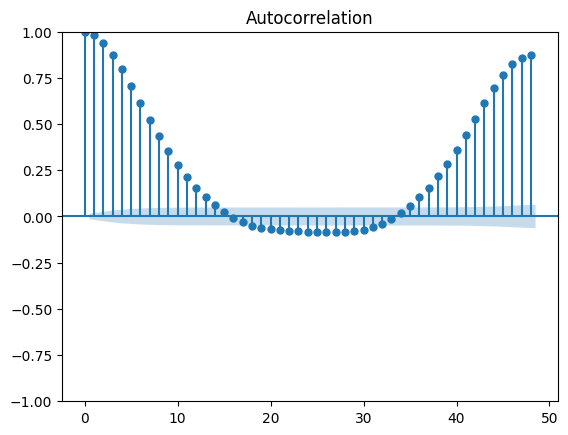

In [14]:
from statsmodels.tsa.seasonal import MSTL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
subset_train = demand.copy()
subset_train = subset_train.set_index("DATETIME")

subset_train = subset_train['2014-01-01':'2014-12-31']
pacf_plot = plot_acf(subset_train['TOTALDEMAND'], lags=48)

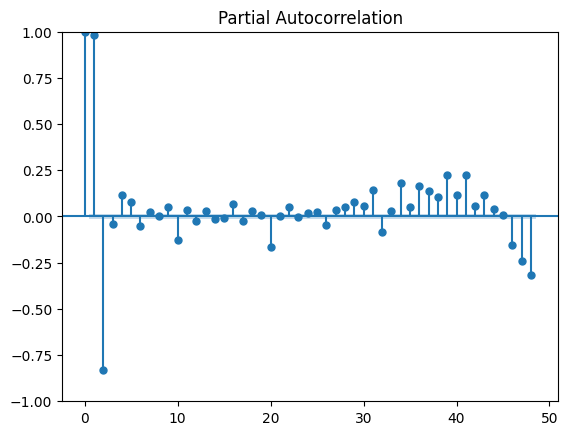

In [15]:
pacf_plot = plot_pacf(subset_train['TOTALDEMAND'], lags=48)

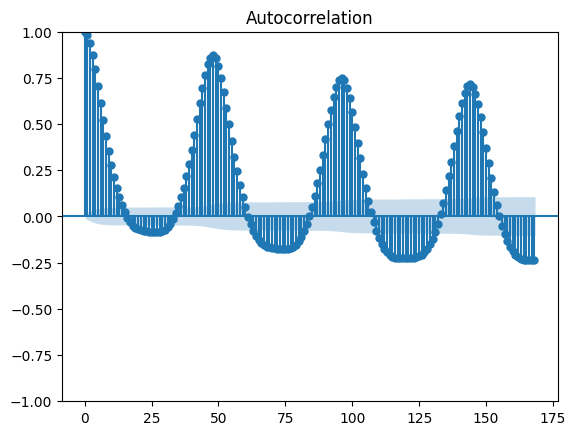

In [16]:
pacf_plot = plot_acf(subset_train['TOTALDEMAND'], lags=int(48*3.5))

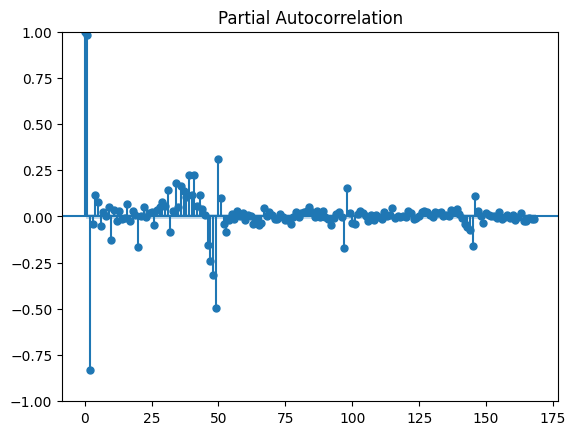

In [17]:
pacf_plot = plot_pacf(subset_train['TOTALDEMAND'], lags=int(48*3.5))

<Figure size 1600x1200 with 0 Axes>

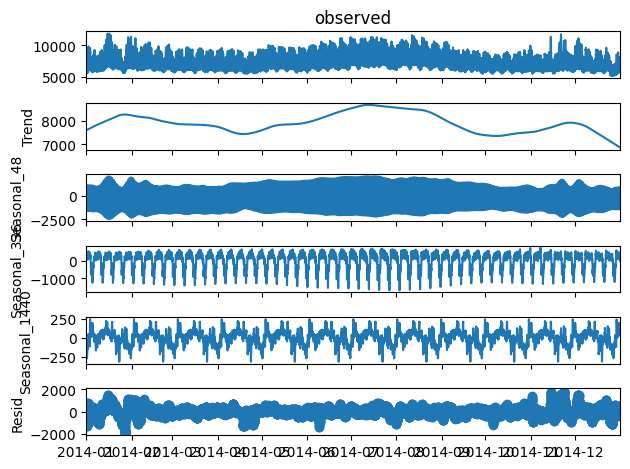

In [18]:
stl = MSTL(
    subset_train['TOTALDEMAND'], 
    windows=(11, 15, 19*4-1),
    periods=(48, 336, 48*30),
    iterate=3,
    stl_kwargs={"seasonal_deg": 0, "inner_iter": 2, "outer_iter": 0})
res = stl.fit()
plt.figure(figsize=(16,12))
fig = res.plot()
plt.show()

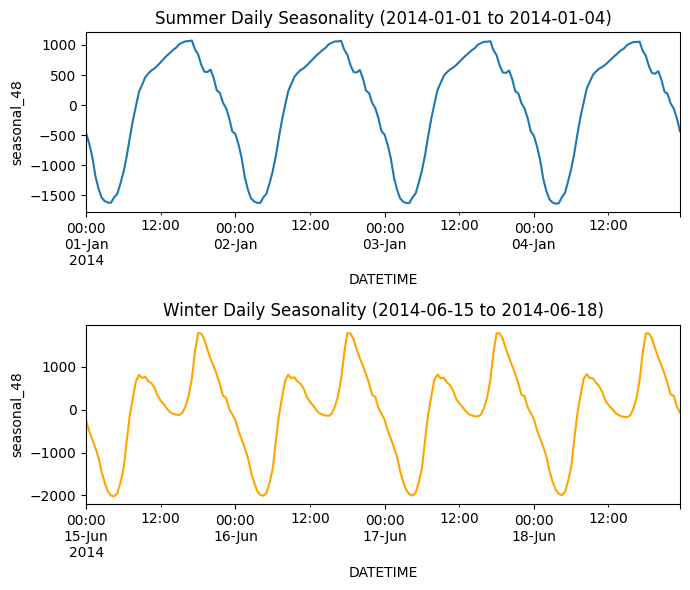

In [19]:
fig, ax = plt.subplots(nrows=2, figsize=[7, 6])
res.seasonal["seasonal_48"]['2014-01-01 00:00:00':'2014-01-04 23:30:00'].plot(ax=ax[0])
ax[0].set_ylabel("seasonal_48")
ax[0].set_title("Summer Daily Seasonality (2014-01-01 to 2014-01-04)")

res.seasonal["seasonal_48"]['2014-06-15 00:00:00':'2014-06-18 23:30:00'].plot(ax=ax[1], color="orange")
ax[1].set_ylabel("seasonal_48")
ax[1].set_title("Winter Daily Seasonality (2014-06-15 to 2014-06-18)")

plt.tight_layout()

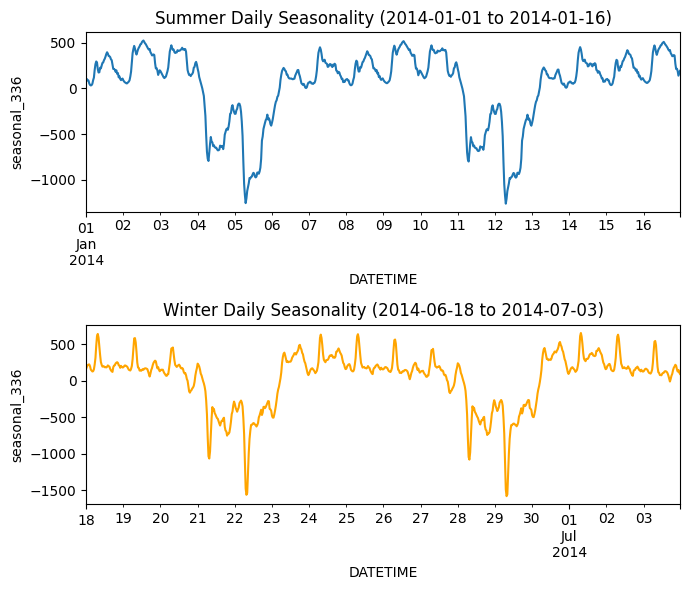

In [20]:
fig, ax = plt.subplots(nrows=2, figsize=[7, 6])
res.seasonal["seasonal_336"]['2014-01-01 00:00:00':'2014-01-16 23:30:00'].plot(ax=ax[0])
ax[0].set_ylabel("seasonal_336")
ax[0].set_title("Summer Daily Seasonality (2014-01-01 to 2014-01-16)")

res.seasonal["seasonal_336"]['2014-06-18 00:00:00':'2014-07-03 23:30:00'].plot(ax=ax[1], color="orange")
ax[1].set_ylabel("seasonal_336")
ax[1].set_title("Winter Daily Seasonality (2014-06-18 to 2014-07-03)")

plt.tight_layout()

### (5.5) Monthly, Day-of-Week and Hourly Demand Analysis
The following plots present the average electricity demand by month, by day-of-week and by hour of the day. These visualisations are used to investigate both seasonal variation and daily consumption patterns in electricity demand. The monthly and day-of-week analysis identifies periods of the year and day-of-week with relatively higher or lower demand respectively, while the hourly analysis illustrates how electricity usage fluctuates throughout a typical day.

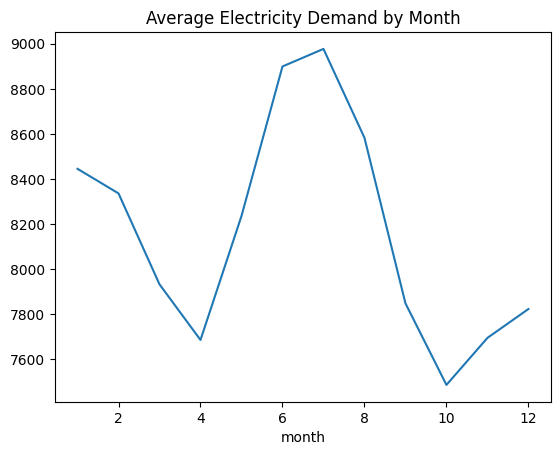

In [21]:
df_merge["month"] = df_merge["DATETIME"].dt.month

df_merge.groupby("month")["TOTALDEMAND"].mean().plot()

plt.title("Average Electricity Demand by Month")

plt.show()

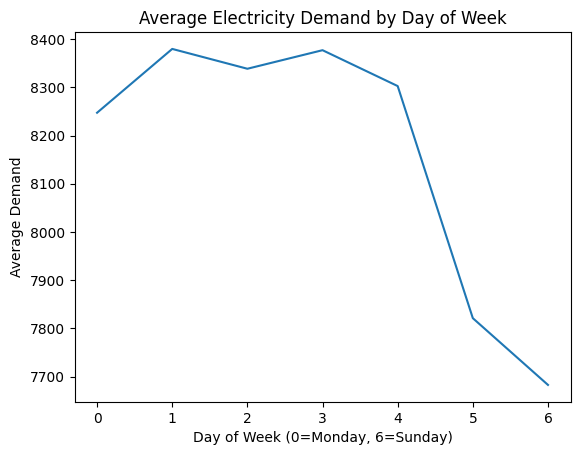

In [22]:
df_merge["dow"] = df_merge["DATETIME"].dt.day_of_week

df_merge.groupby("dow")["TOTALDEMAND"].mean().plot()
plt.title("Average Electricity Demand by Day of Week")
plt.xlabel("Day of Week (0=Monday, 6=Sunday)")
plt.ylabel("Average Demand")
plt.show()

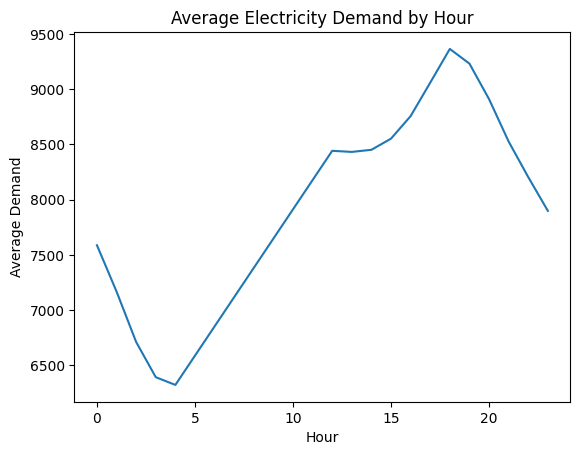

In [23]:
df_merge["hour"] = df_merge["DATETIME"].dt.hour

df_merge.groupby("hour")["TOTALDEMAND"].mean().plot()
plt.title("Average Electricity Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Demand")
plt.show()

The monthly, weekly, and hourly analyses reveal clear multi-scale seasonality in electricity demand. Demand peaks during winter months, likely due to heating requirements, and is lowest during milder periods. Weekly patterns show reduced demand during weekends, reflecting lower industrial and commercial activity.

The hourly profile exhibits a typical daily cycle, with demand peaking in the evening when residential usage is highest.

These patterns confirm that electricity demand is driven by both behavioural and environmental factors, and highlight the importance of incorporating calendar-based features (e.g., hour-of-day, day-of-week, month) into forecasting models.

## Section 5.6 - Additional EDA for Machine Learning

### (5.6.1) Distribution of Total Demand
This plot visualizes the distribution of the TOTALDEMAND to understand its statistical properties.

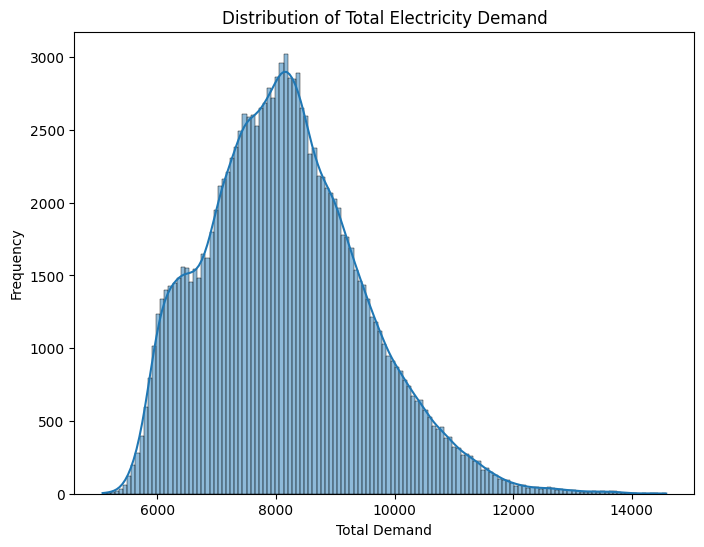

In [24]:
plt.figure(figsize=(8, 6))
sns.histplot(df_merge["TOTALDEMAND"], kde=True)
plt.title("Distribution of Total Electricity Demand")
plt.xlabel("Total Demand")
plt.ylabel("Frequency")
plt.show()

The distribution of electricity demand appears moderately right-skewed, with a longer tail at higher demand levels. This suggests that extreme demand events occur less frequently but may have a significant impact on error-based metrics such as RMSE, which penalises large deviations more heavily. This further emphasises the importance of models that can accurately capture peak demand behaviour.

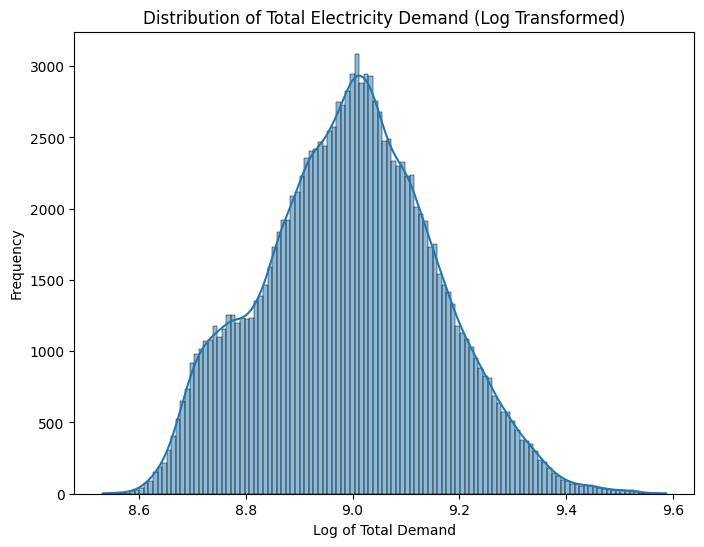

In [26]:
plt.figure(figsize=(8, 6))
sns.histplot(np.log(df_merge["TOTALDEMAND"]), kde=True)
plt.title("Distribution of Total Electricity Demand (Log Transformed)")
plt.xlabel("Log of Total Demand")
plt.ylabel("Frequency")
plt.show()

### (5.6.2) Outlier Detection for Demand and Temperature
Box plots are used to visualize the spread of TOTALDEMAND and TEMPERATURE and identify potential outliers.

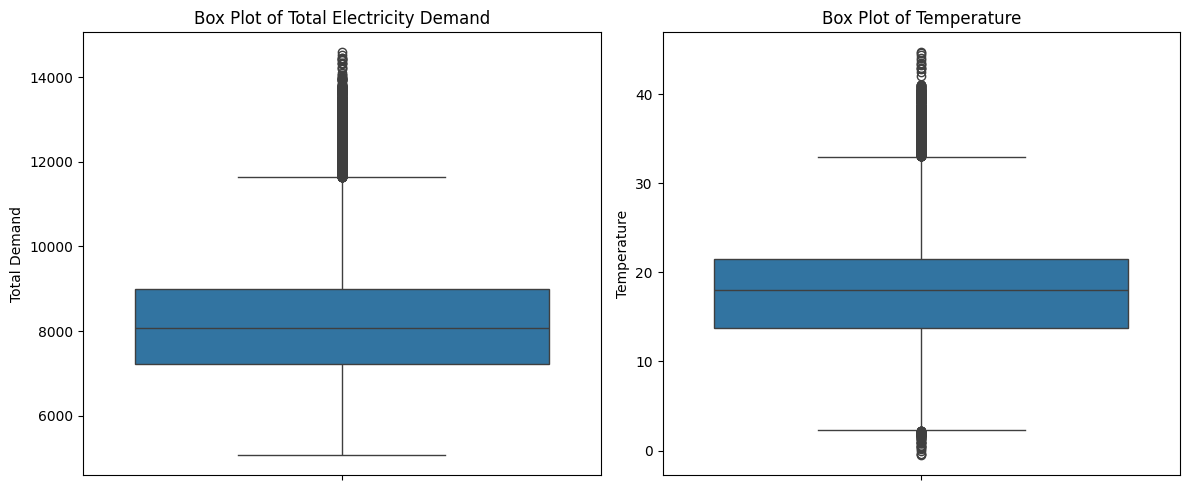

In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_merge["TOTALDEMAND"])
plt.title("Box Plot of Total Electricity Demand")
plt.ylabel("Total Demand")

plt.subplot(1, 2, 2)
sns.boxplot(y=df_merge["TEMPERATURE"])
plt.title("Box Plot of Temperature")
plt.ylabel("Temperature")

plt.tight_layout()
plt.show()

The box plots show some potential outliers in both TOTALDEMAND and TEMPERATURE, particularly at the higher ends. These outliers could represent extreme events (e.g., heatwaves, cold snaps leading to very high demand) or data anomalies that might need further investigation or specific handling during model training.

## Section 6 - Summary

Exploratory data analysis reveals several important characteristics of the electricity demand dataset. The total electricity demand exhibits an approximately normal distribution, slightly skewed to the right, and includes some outliers, especially at higher values, as well as in temperature data. Electricity demand shows clear temporal patterns, including both seasonal variation across months and daily variation across hours. Temperature plays an important role in influencing electricity demand, with demand increasing during periods of extreme cold or high temperatures due to heating and cooling usage.

Furthermore, the aligned provided forecast shows a strong positive relationship with actual demand, indicating that it serves as a meaningful benchmark for model comparison. At the same time, some forecast dispersion remains, especially during higher-demand periods, which highlights the challenge of accurately predicting peak electricity usage.

These comprehensive findings provide a robust foundation for developing and refining predictive models for electricity demand, by highlighting key features, potential data challenges, and temporal structures.